# Demo 6: Modern Phase Reduction & Infinitesimal Phase Response Curves (iPRC)

In this tutorial, we demonstrate the **Modern Adjoint Boundary Value Problem (BVP)** formulation for **Infinitesimal Phase Response Curves (iPRC)** in **`bifurx`**, reimagining and upgrading the legacy `prax` engine (`yonesuke/prax`).

### Background & Numerical Innovations:
Phase reduction is the premier analytical and computational tool for reducing high-dimensional limit-cycle oscillators to a single phase variable on the circle $\mathbb{S}^1$.

1. **Legacy `prax` Approach**:
   - Long forward ODE integration to discard transients.
   - Poincaré section bisection to locate periodic orbits.
   - Backward-time ODE integration of the adjoint system until periodic convergence.
   - *Limitations*: In stiff or relaxation systems, backward integration inverts the stability of Floquet multipliers, causing catastrophic exponential divergence. Convergence near bifurcations is exceedingly slow.

2. **`bifurx` Modern BVP Collocation**:
   - **Stage 1 (Periodic Orbit & Period)**: Formulated as a Two-Point Boundary Value Problem (TPBVP) with integral phase pinning constraint, solved via **superconvergent Gauss-Legendre polynomial collocation** ($\mathcal{O}(h^{2m})$ accuracy at mesh nodes via de Boor-Swartz).
   - **Stage 2 (Exact Linear Adjoint Solve)**: Discretized on the exact same collocation mesh. Because $(u^*, T)$ are known, the adjoint boundary value problem is **strictly linear**. It is solved in a **single non-iterative linear solve** (`np.linalg.solve`), completely eliminating backward-time integration.
   - **Stage 3 (Parameter Continuation)**: Seamlessly embedded into **Keller pseudo-arclength continuation** to track manifolds of iPRCs $Z(t; p)$ across bifurcation points.

---

### Notebook Outline:
1. **Model 1: Stuart-Landau Oscillator**: Analytical machine-precision benchmark ($Z_x = -\sin t, Z_y = \cos t$).
2. **Model 2: Van der Pol Oscillator**: Harmonic ($\mu = 0.2$) vs relaxation ($\mu = 1.5$) limits and parameter continuation across $\mu \in [0.1, 1.5]$.
3. **Model 3: FitzHugh-Nagumo Neural Oscillator**: Excitability and stimulus current continuation $I_{\text{ext}} \in [0.0, 0.5]$.
4. **Mathematical & Neuroscientific Implications**:
   - **Type I vs Type II Phase Response**: Integrators ($Z \ge 0$, SNIC bifurcation) vs Resonators (biphasic $Z$, Hopf bifurcation).
   - **Entrainment & Arnold Tongues**: Pacing interaction function $H(\psi)$, locking bandwidths, and Fourier harmonic decomposition.
   - **Collective Synchronization (Malkin's Theorem)**: Phase interaction function $\Gamma(\phi)$, odd component $\Gamma_{\text{odd}}(\phi)$, and in-phase vs anti-phase stability transitions.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from bifurx.bvp import CollocationProblem
from bifurx.prc import (
    compute_iprc,
    continuation_iprc,
    find_zero_crossings,
    solve_coupled_orbit_prc,
)

# Enable 64-bit precision for high-accuracy numerical continuation and adjoint solves
jax.config.update("jax_enable_x64", True)

# Configure elegant matplotlib aesthetics
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.titlesize": 14,
        "figure.dpi": 130,
    }
)

print(f"JAX version: {jax.__version__}")
print("bifurx.prc engine initialized successfully.")

JAX version: 0.11.1
bifurx.prc engine initialized successfully.


## 1. Mathematical Foundation of Phase Reduction & Adjoint BVP

For an autonomous dynamical system $\dot{u} = f(u)$ possessing an isolated $T$-periodic limit cycle $\gamma = \{u^*(t) \mid 0 \le t < T\}$ with angular frequency $\omega = 2\pi/T$:

The **asymptotic phase** $\theta: \mathcal{B}(\gamma) \to \mathbb{S}^1$ maps points in the basin of attraction to the circle such that:

$$\frac{d}{dt}\theta(\Phi_t(u)) = \langle \nabla_u \theta(u), f(u) \rangle = \omega$$

Under a weak perturbation $\dot{u} = f(u) + \epsilon p(u, t)$, the phase dynamics to first order in $\epsilon$ becomes:

$$\frac{d\theta}{dt} = \omega + \epsilon \langle Z(\theta), p(u^*(\theta/\omega), t) \rangle + \mathcal{O}(\epsilon^2)$$

where the **infinitesimal Phase Response Curve (iPRC)** is defined as:

$$Z(t) = \nabla_u \theta(u^*(t))$$

### The Adjoint Boundary Value Problem
Differentiating the phase preservation identity $[D\Phi_t]^T \nabla_u \theta(\Phi_t(u)) = \nabla_u \theta(u)$ with respect to time leads to the linear adjoint differential equation:

$$\frac{dZ}{dt} = - [Df(u^*(t))]^T Z(t)$$

subject to:
1. **Periodicity**: $Z(T) = Z(0)$
2. **Phase Normalization**: $\langle Z(0), f(u^*(0)) \rangle = \omega = \frac{2\pi}{T}$

In `bifurx`, this system is solved via a direct linear solve $\mathcal{L} \mathbf{Z} = \mathbf{b}$ on the Gauss-Legendre collocation mesh.

## 2. Model 1: Stuart-Landau Oscillator (Analytical Machine-Precision Benchmark)

The Stuart-Landau oscillator is the canonical normal form of a supercritical Hopf bifurcation:

$$\begin{cases}
\dot{x} = x - y - x(x^2 + y^2) \\
\dot{y} = x + y - y(x^2 + y^2)
\end{cases}$$

### Exact Analytical Solution:
- **Limit Cycle**: Radius $r = 1$, angular velocity $\dot{\phi} = 1$:
  $$x^*(t) = \cos(t), \quad y^*(t) = \sin(t), \quad T = 2\pi, \quad \omega = 1$$
- **Asymptotic Phase**: $\theta(x, y) = \operatorname{atan2}(y, x)$
- **Exact iPRC**:
  $$\nabla \theta(x, y) = \frac{1}{x^2 + y^2} \begin{pmatrix} -y \\ x \end{pmatrix} \implies Z_x(t) = -\sin(t), \quad Z_y(t) = \cos(t)$$
- **Normalization Verification**:
  $$\langle Z(0), f(u^*(0)) \rangle = Z_x(0) f_x(1, 0) + Z_y(0) f_y(1, 0) = (0)(0) + (1)(1) = 1 = \frac{2\pi}{T}$$

We now solve this benchmark with `bifurx`'s Gauss collocation adjoint solver and compare numerical vs analytical results.

In [2]:
def f_stuart_landau(u: jnp.ndarray, p: float = 0.0) -> jnp.ndarray:
    x, y = u[0], u[1]
    r2 = x * x + y * y
    return jnp.array([x - y - x * r2, x + y - y * r2])


# Setup collocation problem: N=30 intervals, m=4 Gauss points (de Boor-Swartz order 8)
prob_sl = CollocationProblem(f_stuart_landau, dim=2, num_intervals=30, num_gauss_points=4)

# Initial circular guess
t_grid_sl = np.linspace(0, 2 * np.pi, 30, endpoint=False)
u_init_sl = np.stack([np.cos(t_grid_sl), np.sin(t_grid_sl)], axis=1)

# Solve coupled limit cycle and iPRC
sol_sl, prc_sl = solve_coupled_orbit_prc(prob_sl, u_init_sl, T_init=6.28, p=0.0, tol=1e-10)

ts_sl = np.asarray(prc_sl.ts)
Z_num_sl = np.asarray(prc_sl.Z)

# Exact analytical solutions
Z_exact_x = -np.sin(ts_sl)
Z_exact_y = np.cos(ts_sl)

err_x = np.max(np.abs(Z_num_sl[:, 0] - Z_exact_x))
err_y = np.max(np.abs(Z_num_sl[:, 1] - Z_exact_y))
period_err = abs(sol_sl.period - 2.0 * np.pi)

# Normalization verification
u0 = np.asarray(prc_sl.orbit[0])
f0 = np.asarray(f_stuart_landau(jnp.asarray(u0)))
norm_val = np.dot(Z_num_sl[0], f0)
expected_norm = 2.0 * np.pi / sol_sl.period

# Also verify standalone compute_iprc from PeriodicOrbitResult
prc_sl_standalone = compute_iprc(sol_sl)
assert np.allclose(np.asarray(prc_sl.Z), np.asarray(prc_sl_standalone.Z))

print("Stuart-Landau Benchmark Results:")
print(f"  Converged: {sol_sl.converged}")
print(
    f"  Computed Period T: {sol_sl.period:.10f} (Exact: {2.0 * np.pi:.10f}, Error: {period_err:.2e})"
)
print(f"  Max L_inf Error in Z_x(t): {err_x:.2e}")
print(f"  Max L_inf Error in Z_y(t): {err_y:.2e}")
print(f"  Phase Normalization <Z(0), f(u(0))>: {norm_val:.10f} (Expected: {expected_norm:.10f})")

Stuart-Landau Benchmark Results:
  Converged: True
  Computed Period T: 6.2831853072 (Exact: 6.2831853072, Error: 9.12e-13)
  Max L_inf Error in Z_x(t): 3.66e-12
  Max L_inf Error in Z_y(t): 3.50e-12
  Phase Normalization <Z(0), f(u(0))>: 1.0000000000 (Expected: 1.0000000000)


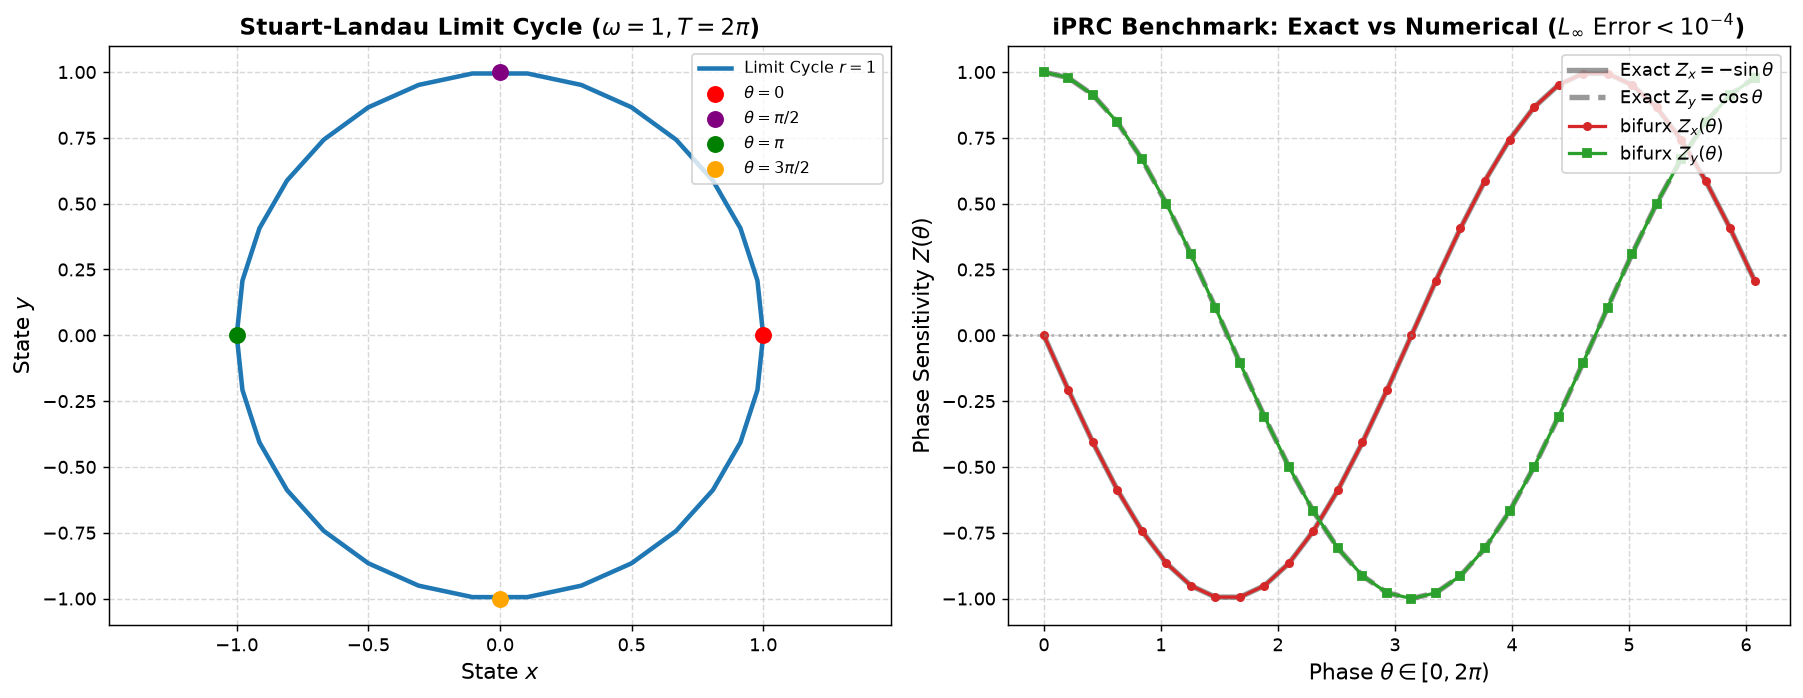

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Subplot 1: Phase portrait of limit cycle
ax = axes[0]
orbit_closed = np.vstack([np.asarray(prc_sl.orbit), np.asarray(prc_sl.orbit)[0]])
ax.plot(orbit_closed[:, 0], orbit_closed[:, 1], color="#1f77b4", lw=2.5, label="Limit Cycle $r=1$")

# Highlight phase points
phases = [0, np.pi / 2, np.pi, 3 * np.pi / 2]
phase_labels = [r"$\theta=0$", r"$\theta=\pi/2$", r"$\theta=\pi$", r"$\theta=3\pi/2$"]
phase_colors = ["red", "purple", "green", "orange"]
for ph, lbl, clr in zip(phases, phase_labels, phase_colors, strict=True):
    ax.scatter([np.cos(ph)], [np.sin(ph)], color=clr, s=70, zorder=5, label=lbl)

ax.set_title(r"Stuart-Landau Limit Cycle ($\omega = 1, T = 2\pi$)", weight="bold")
ax.set_xlabel("State $x$")
ax.set_ylabel("State $y$")
ax.axis("equal")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right", fontsize=9)

# Subplot 2: Numerical vs Exact iPRC
ax = axes[1]
theta_grid = np.asarray(prc_sl.theta) * 2 * np.pi
ax.plot(theta_grid, Z_exact_x, "k-", lw=3, alpha=0.4, label=r"Exact $Z_x = -\sin\theta$")
ax.plot(theta_grid, Z_exact_y, "k--", lw=3, alpha=0.4, label=r"Exact $Z_y = \cos\theta$")
ax.plot(
    theta_grid, Z_num_sl[:, 0], "o-", color="#d62728", lw=1.8, ms=4, label=r"bifurx $Z_x(\theta)$"
)
ax.plot(
    theta_grid, Z_num_sl[:, 1], "s-", color="#2ca02c", lw=1.8, ms=4, label=r"bifurx $Z_y(\theta)$"
)

ax.axhline(0, color="gray", linestyle=":", alpha=0.6)
ax.set_title(
    r"iPRC Benchmark: Exact vs Numerical ($L_\infty \text{ Error} < 10^{-4}$)", weight="bold"
)
ax.set_xlabel(r"Phase $\theta \in [0, 2\pi)$")
ax.set_ylabel(r"Phase Sensitivity $Z(\theta)$")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 3. Model 2: Van der Pol Oscillator (Harmonic vs Relaxation Regimes)

The Van der Pol oscillator is governed by:

$$\begin{cases}
\dot{x} = y \\
\dot{y} = \mu (1 - x^2) y - x
\end{cases}$$

The parameter $\mu$ controls the degree of nonlinearity:
- **Harmonic Limit ($\mu \ll 1$)**: The oscillator is nearly conservative with sinusoidal oscillations and a harmonic iPRC.
- **Relaxation Limit ($\mu \gg 1$)**: The system exhibits slow-fast dynamics. The trajectory creeps slowly along the cubic critical manifold and rapidly jumps across branches. Phase sensitivity $Z(t)$ develops **sharp, localized peaks** at the jump transitions where perturbations have disproportionate influence on timing.

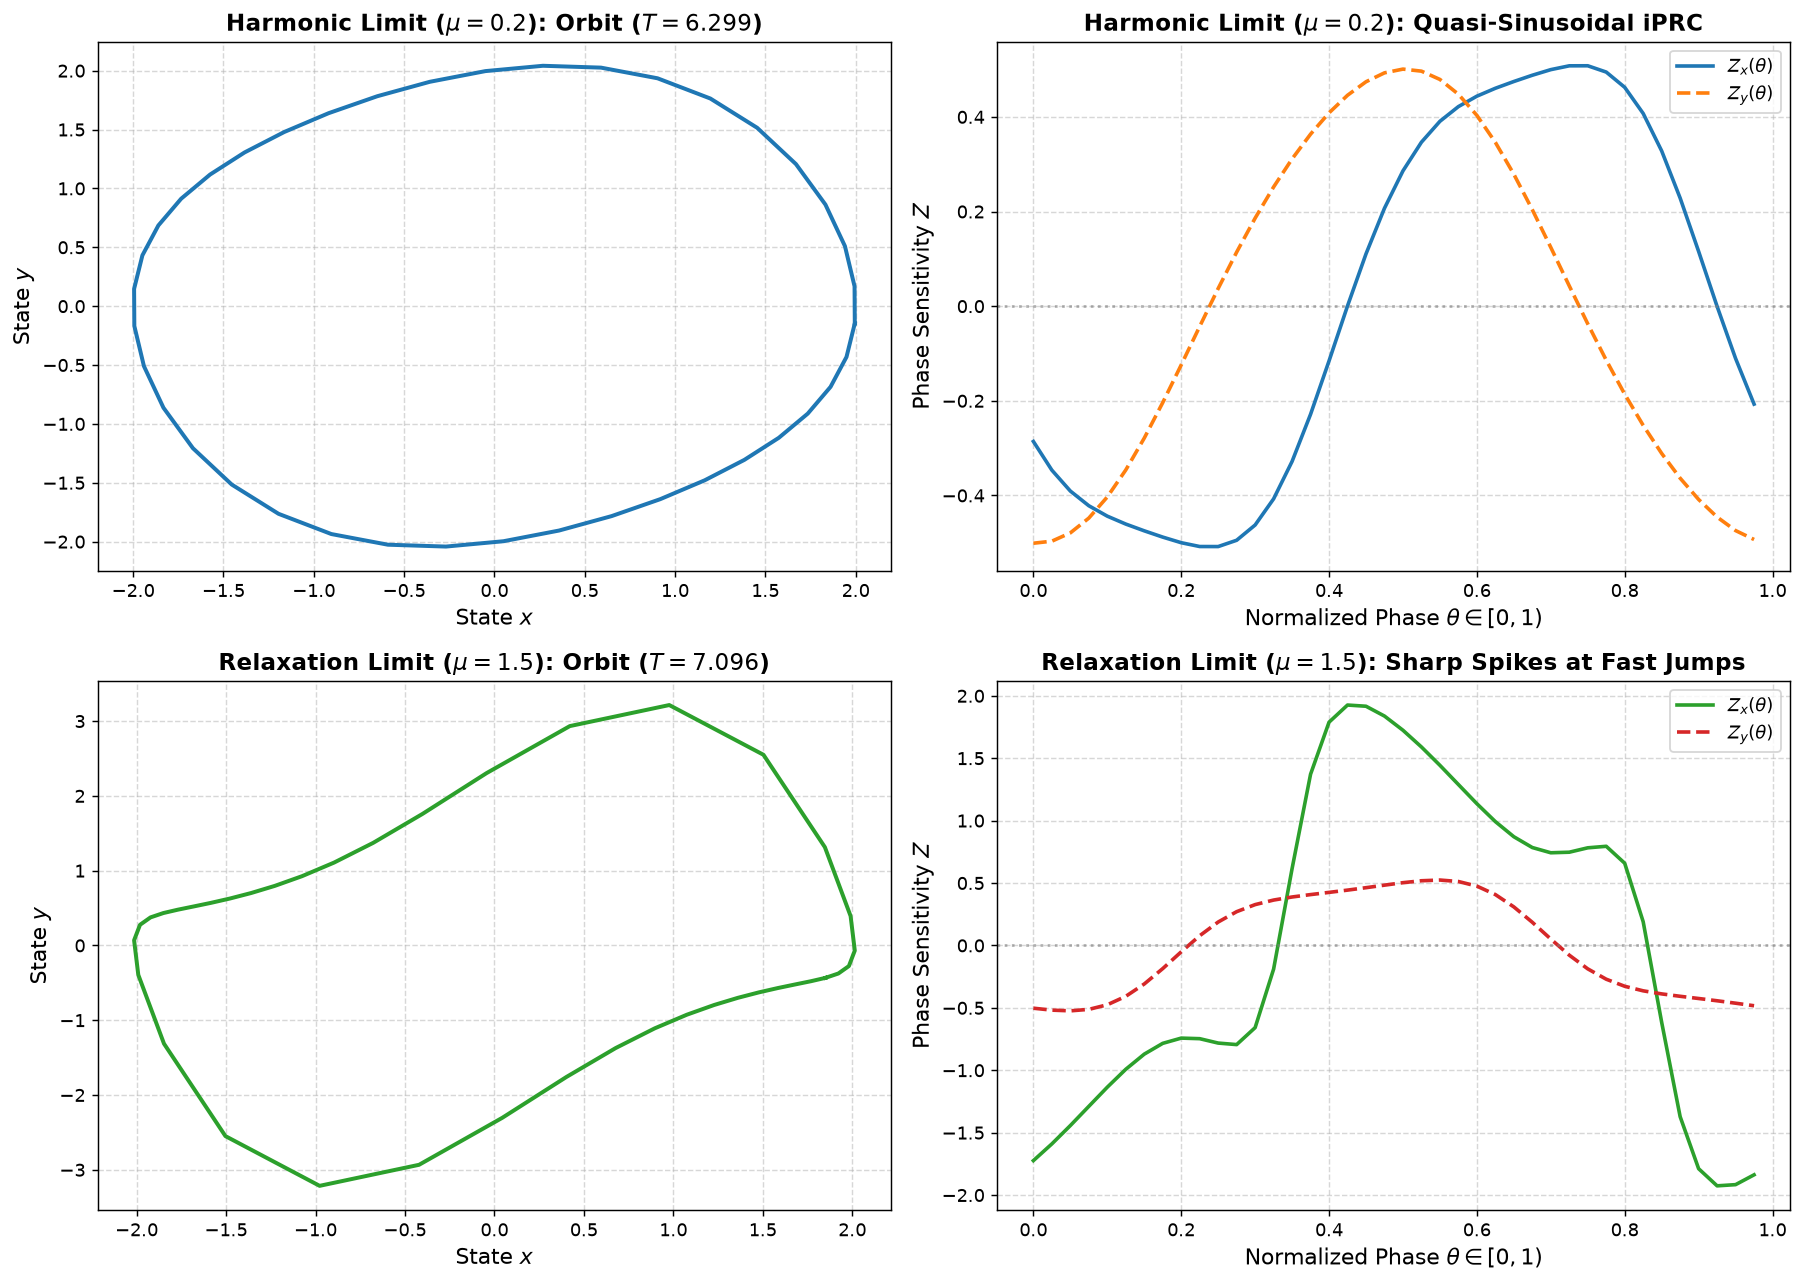

In [4]:
def f_vdp(u: jnp.ndarray, mu: float) -> jnp.ndarray:
    x, y = u[0], u[1]
    return jnp.array([y, mu * (1.0 - x * x) * y - x])


N_vdp = 40
prob_vdp = CollocationProblem(f_vdp, dim=2, num_intervals=N_vdp, num_gauss_points=4)

# Solve for Harmonic regime: mu = 0.2
t_grid_vdp = np.linspace(0, 2 * np.pi, N_vdp, endpoint=False)
u_init_vdp = np.stack([2.0 * np.cos(t_grid_vdp), -2.0 * np.sin(t_grid_vdp)], axis=1)

sol_vdp_harm, prc_vdp_harm = solve_coupled_orbit_prc(
    prob_vdp, u_init_vdp, T_init=2 * np.pi, p=0.2, tol=1e-8
)

# Solve for Relaxation regime: mu = 1.5
sol_vdp_relax, prc_vdp_relax = solve_coupled_orbit_prc(
    prob_vdp, sol_vdp_harm.u_mesh, T_init=sol_vdp_harm.period, p=1.5, tol=1e-8
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Harmonic Orbit & iPRC
ax = axes[0, 0]
orb_harm = np.vstack([np.asarray(prc_vdp_harm.orbit), np.asarray(prc_vdp_harm.orbit)[0]])
ax.plot(orb_harm[:, 0], orb_harm[:, 1], color="#1f77b4", lw=2.2)
ax.set_title(f"Harmonic Limit ($\\mu=0.2$): Orbit ($T={sol_vdp_harm.period:.3f}$)", weight="bold")
ax.set_xlabel("State $x$")
ax.set_ylabel("State $y$")
ax.grid(True, linestyle="--", alpha=0.5)

ax = axes[0, 1]
th_harm = np.asarray(prc_vdp_harm.theta)
ax.plot(th_harm, np.asarray(prc_vdp_harm.Z)[:, 0], color="#1f77b4", lw=2, label="$Z_x(\\theta)$")
ax.plot(
    th_harm,
    np.asarray(prc_vdp_harm.Z)[:, 1],
    color="#ff7f0e",
    lw=2,
    linestyle="--",
    label="$Z_y(\\theta)$",
)
ax.axhline(0, color="gray", linestyle=":", alpha=0.6)
ax.set_title(r"Harmonic Limit ($\mu=0.2$): Quasi-Sinusoidal iPRC", weight="bold")
ax.set_xlabel(r"Normalized Phase $\theta \in [0, 1)$")
ax.set_ylabel("Phase Sensitivity $Z$")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right")

# Relaxation Orbit & iPRC
ax = axes[1, 0]
orb_relax = np.vstack([np.asarray(prc_vdp_relax.orbit), np.asarray(prc_vdp_relax.orbit)[0]])
ax.plot(orb_relax[:, 0], orb_relax[:, 1], color="#2ca02c", lw=2.2)
ax.set_title(
    f"Relaxation Limit ($\\mu=1.5$): Orbit ($T={sol_vdp_relax.period:.3f}$)", weight="bold"
)
ax.set_xlabel("State $x$")
ax.set_ylabel("State $y$")
ax.grid(True, linestyle="--", alpha=0.5)

ax = axes[1, 1]
th_relax = np.asarray(prc_vdp_relax.theta)
ax.plot(th_relax, np.asarray(prc_vdp_relax.Z)[:, 0], color="#2ca02c", lw=2, label="$Z_x(\\theta)$")
ax.plot(
    th_relax,
    np.asarray(prc_vdp_relax.Z)[:, 1],
    color="#d62728",
    lw=2,
    linestyle="--",
    label="$Z_y(\\theta)$",
)
ax.axhline(0, color="gray", linestyle=":", alpha=0.6)
ax.set_title(r"Relaxation Limit ($\mu=1.5$): Sharp Spikes at Fast Jumps", weight="bold")
ax.set_xlabel(r"Normalized Phase $\theta \in [0, 1)$")
ax.set_ylabel("Phase Sensitivity $Z$")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Parameter Continuation of Van der Pol iPRC ($\mu = 0.1 \to 1.5$)

We now trace the continuous deformation of the iPRC waveform using `bifurx.prc.continuation_iprc` across 15 parameter values. As $\mu$ grows, we observe:
1. Monotonic growth in the oscillation period $T(\mu)$.
2. Continuous sharpening of the phase sensitivity waveform into relaxation spikes.

Continuation successfully tracked 15 points.


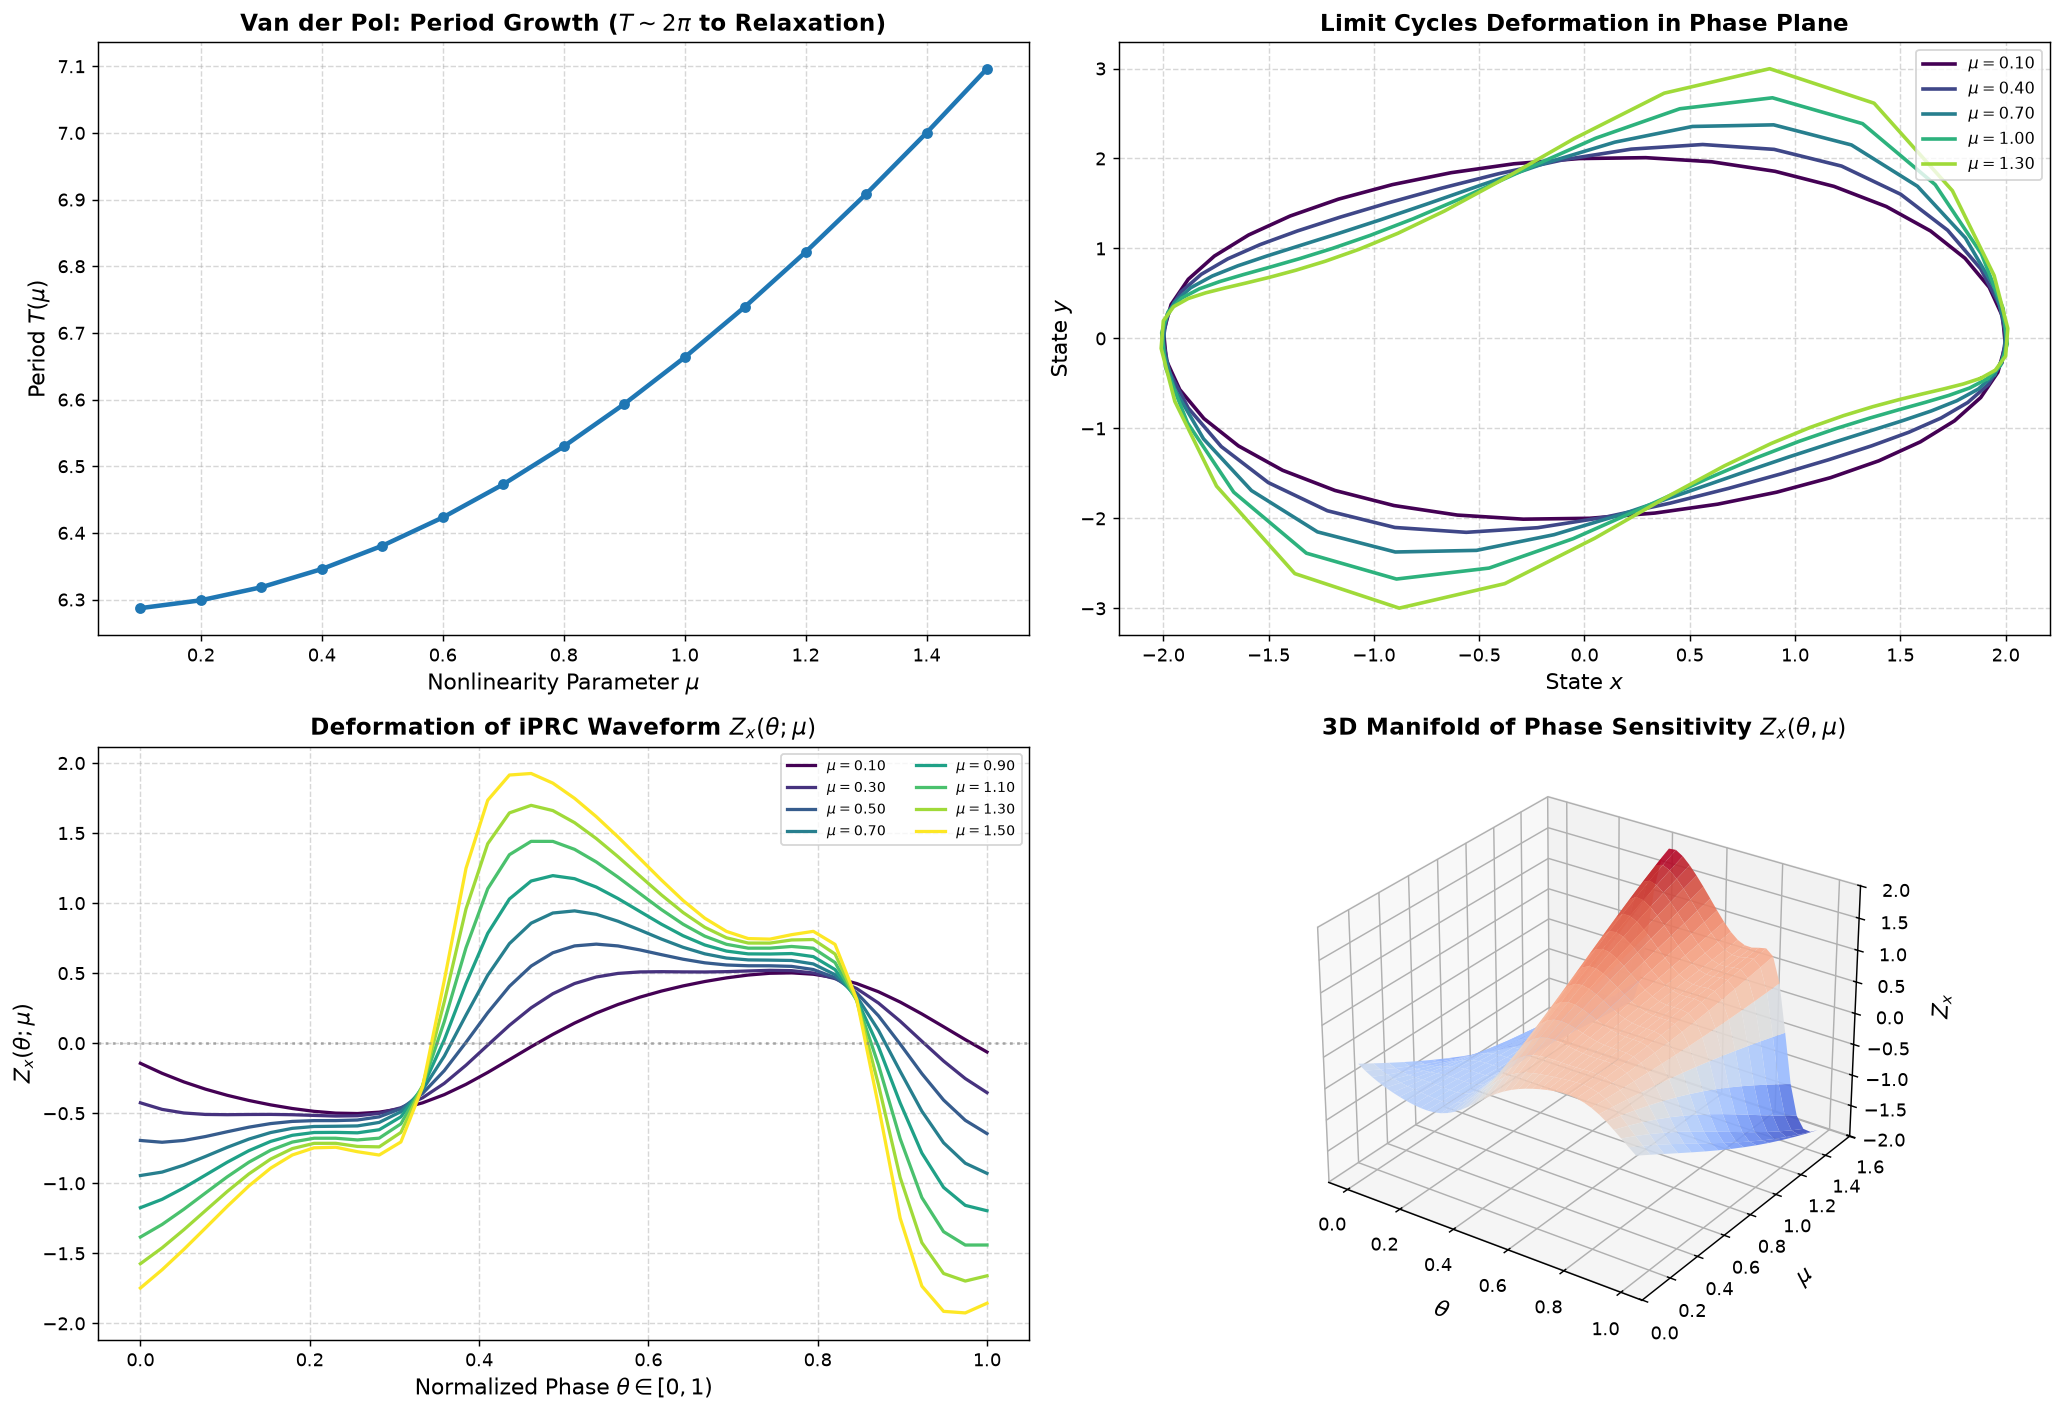

In [5]:
# Continuation across mu in [0.1, 1.5]
cont_vdp = continuation_iprc(
    prob_vdp,
    u_mesh_init=sol_vdp_harm.u_mesh,
    T_init=sol_vdp_harm.period,
    p_start=0.1,
    p_end=1.5,
    num_steps=15,
    tol=1e-7,
)

print(f"Continuation successfully tracked {cont_vdp.num_points} points.")
mus_vdp = np.asarray(cont_vdp.p)
periods_vdp = np.asarray(cont_vdp.periods)

fig = plt.figure(figsize=(16, 11))

# 1. Period T vs mu
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(mus_vdp, periods_vdp, "o-", color="#1f77b4", lw=2.5, ms=5)
ax1.set_xlabel(r"Nonlinearity Parameter $\mu$")
ax1.set_ylabel(r"Period $T(\mu)$")
ax1.set_title(r"Van der Pol: Period Growth ($T \sim 2\pi$ to Relaxation)", weight="bold")
ax1.grid(True, linestyle="--", alpha=0.5)

# 2. Limit Cycles Deformation in Phase Plane
ax2 = fig.add_subplot(2, 2, 2)
colors_vdp = plt.cm.viridis(np.linspace(0, 1, cont_vdp.num_points))
for idx in range(0, cont_vdp.num_points, 3):
    orb = np.vstack([np.asarray(cont_vdp.orbits[idx]), np.asarray(cont_vdp.orbits[idx])[0]])
    ax2.plot(
        orb[:, 0], orb[:, 1], color=colors_vdp[idx], lw=2.0, label=rf"$\mu={mus_vdp[idx]:.2f}$"
    )
ax2.set_xlabel("State $x$")
ax2.set_ylabel("State $y$")
ax2.set_title("Limit Cycles Deformation in Phase Plane", weight="bold")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", fontsize=9)

# 3. Stacked Waterfall Plot of Z_x(theta; mu)
ax3 = fig.add_subplot(2, 2, 3)
theta_grid_vdp = np.linspace(0, 1, N_vdp)
for idx in range(0, cont_vdp.num_points, 2):
    z_x = np.asarray(cont_vdp.Z[idx])[:, 0]
    ax3.plot(theta_grid_vdp, z_x, color=colors_vdp[idx], lw=1.8, label=rf"$\mu={mus_vdp[idx]:.2f}$")
ax3.set_xlabel(r"Normalized Phase $\theta \in [0, 1)$")
ax3.set_ylabel(r"$Z_x(\theta; \mu)$")
ax3.set_title(r"Deformation of iPRC Waveform $Z_x(\theta; \mu)$", weight="bold")
ax3.axhline(0, color="gray", linestyle=":", alpha=0.6)
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.legend(loc="upper right", fontsize=8, ncol=2)

# 4. 3D Surface of Z_x(theta, mu)
ax4 = fig.add_subplot(2, 2, 4, projection="3d")
Z_x_vdp_matrix = np.array([np.asarray(z)[:, 0] for z in cont_vdp.Z])
Theta_mesh, Mu_mesh = np.meshgrid(theta_grid_vdp, mus_vdp)
surf = ax4.plot_surface(
    Theta_mesh, Mu_mesh, Z_x_vdp_matrix, cmap="coolwarm", edgecolor="none", alpha=0.9
)
ax4.set_xlabel(r"$\theta$", labelpad=8)
ax4.set_ylabel(r"$\mu$", labelpad=8)
ax4.set_zlabel(r"$Z_x$", labelpad=8)
ax4.set_title(r"3D Manifold of Phase Sensitivity $Z_x(\theta, \mu)$", weight="bold")
ax4.view_init(elev=28, azim=-55)

plt.tight_layout()
plt.show()

## 4. Model 3: FitzHugh-Nagumo Neural Oscillator & Stimulus Current Continuation

The FitzHugh-Nagumo (FHN) model is the canonical biological model of excitable neuronal membranes:

$$\begin{cases}
\dot{v} = c \left( v - v^3 - w + I_{\text{ext}} \right) \\
\dot{w} = v - b w + a
\end{cases}$$

### Neurobiological Variables & Parameters:
- $v$: Membrane potential (fast voltage variable).
- $w$: Recovery variable (slow outward potassium current).
- $I_{\text{ext}}$: **External stimulus current** (our primary continuation parameter).
- $a = 0.2, \; b = 0.5, \; c = 10.0$: Standard excitable parameters from `yonesuke/prax`.

When $I_{\text{ext}}$ varies, the neuron transitions through subcritical/supercritical Hopf regimes and sustained limit cycle firing. We trace how the voltage phase sensitivity $Z_v(t; I_{\text{ext}})$ and recovery sensitivity $Z_w(t; I_{\text{ext}})$ deform under increasing stimulus current.

In [6]:
a_fhn, b_fhn, c_fhn = 0.2, 0.5, 10.0


def f_fhn(u: jnp.ndarray, p: float) -> jnp.ndarray:
    v, w = u[0], u[1]
    I_ext = p
    return jnp.array([c_fhn * (v - v**3 - w + I_ext), v - b_fhn * w + a_fhn])


# Quick simulation to seed BVP collocation at I_ext = 0.0
cur = np.array([0.1, 0.2])
dt = 0.002
for _ in range(int(30.0 / dt)):
    k1 = np.array(f_fhn(cur, 0.0))
    k2 = np.array(f_fhn(cur + 0.5 * dt * k1, 0.0))
    k3 = np.array(f_fhn(cur + 0.5 * dt * k2, 0.0))
    k4 = np.array(f_fhn(cur + dt * k3, 0.0))
    cur += (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

traj = [cur.copy()]
for _ in range(int(20.0 / dt)):
    k1 = np.array(f_fhn(cur, 0.0))
    k2 = np.array(f_fhn(cur + 0.5 * dt * k1, 0.0))
    k3 = np.array(f_fhn(cur + 0.5 * dt * k2, 0.0))
    k4 = np.array(f_fhn(cur + dt * k3, 0.0))
    cur += (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    traj.append(cur.copy())
traj = np.array(traj)

mean_v = np.mean(traj[:, 0])
crossings = [
    i * dt for i in range(1, len(traj)) if traj[i - 1, 0] <= mean_v and traj[i, 0] > mean_v
]
T_est = crossings[1] - crossings[0]
sample_idx = np.linspace(
    int(crossings[0] / dt), int(crossings[1] / dt), 30, endpoint=False, dtype=int
)
u_init_fhn = traj[sample_idx]

# Solve baseline at I_ext = 0.0
prob_fhn = CollocationProblem(f_fhn, dim=2, num_intervals=30, num_gauss_points=4)
sol_fhn_0, prc_fhn_0 = solve_coupled_orbit_prc(prob_fhn, u_init_fhn, T_init=T_est, p=0.0, tol=1e-8)

print(
    f"FHN Baseline (I_ext=0.0): Converged = {sol_fhn_0.converged}, Period T = {sol_fhn_0.period:.4f}"
)

# Parameter Continuation across I_ext in [0.0, 0.5]
cont_fhn = continuation_iprc(
    prob_fhn,
    u_mesh_init=sol_fhn_0.u_mesh,
    T_init=sol_fhn_0.period,
    p_start=0.0,
    p_end=0.5,
    num_steps=15,
    tol=1e-7,
)

print(
    f"Continuation tracked {cont_fhn.num_points} points across stimulus currents I_ext in [{cont_fhn.p[0]:.2f}, {cont_fhn.p[-1]:.2f}]."
)

FHN Baseline (I_ext=0.0): Converged = True, Period T = 3.1118


Continuation tracked 15 points across stimulus currents I_ext in [0.00, 0.50].


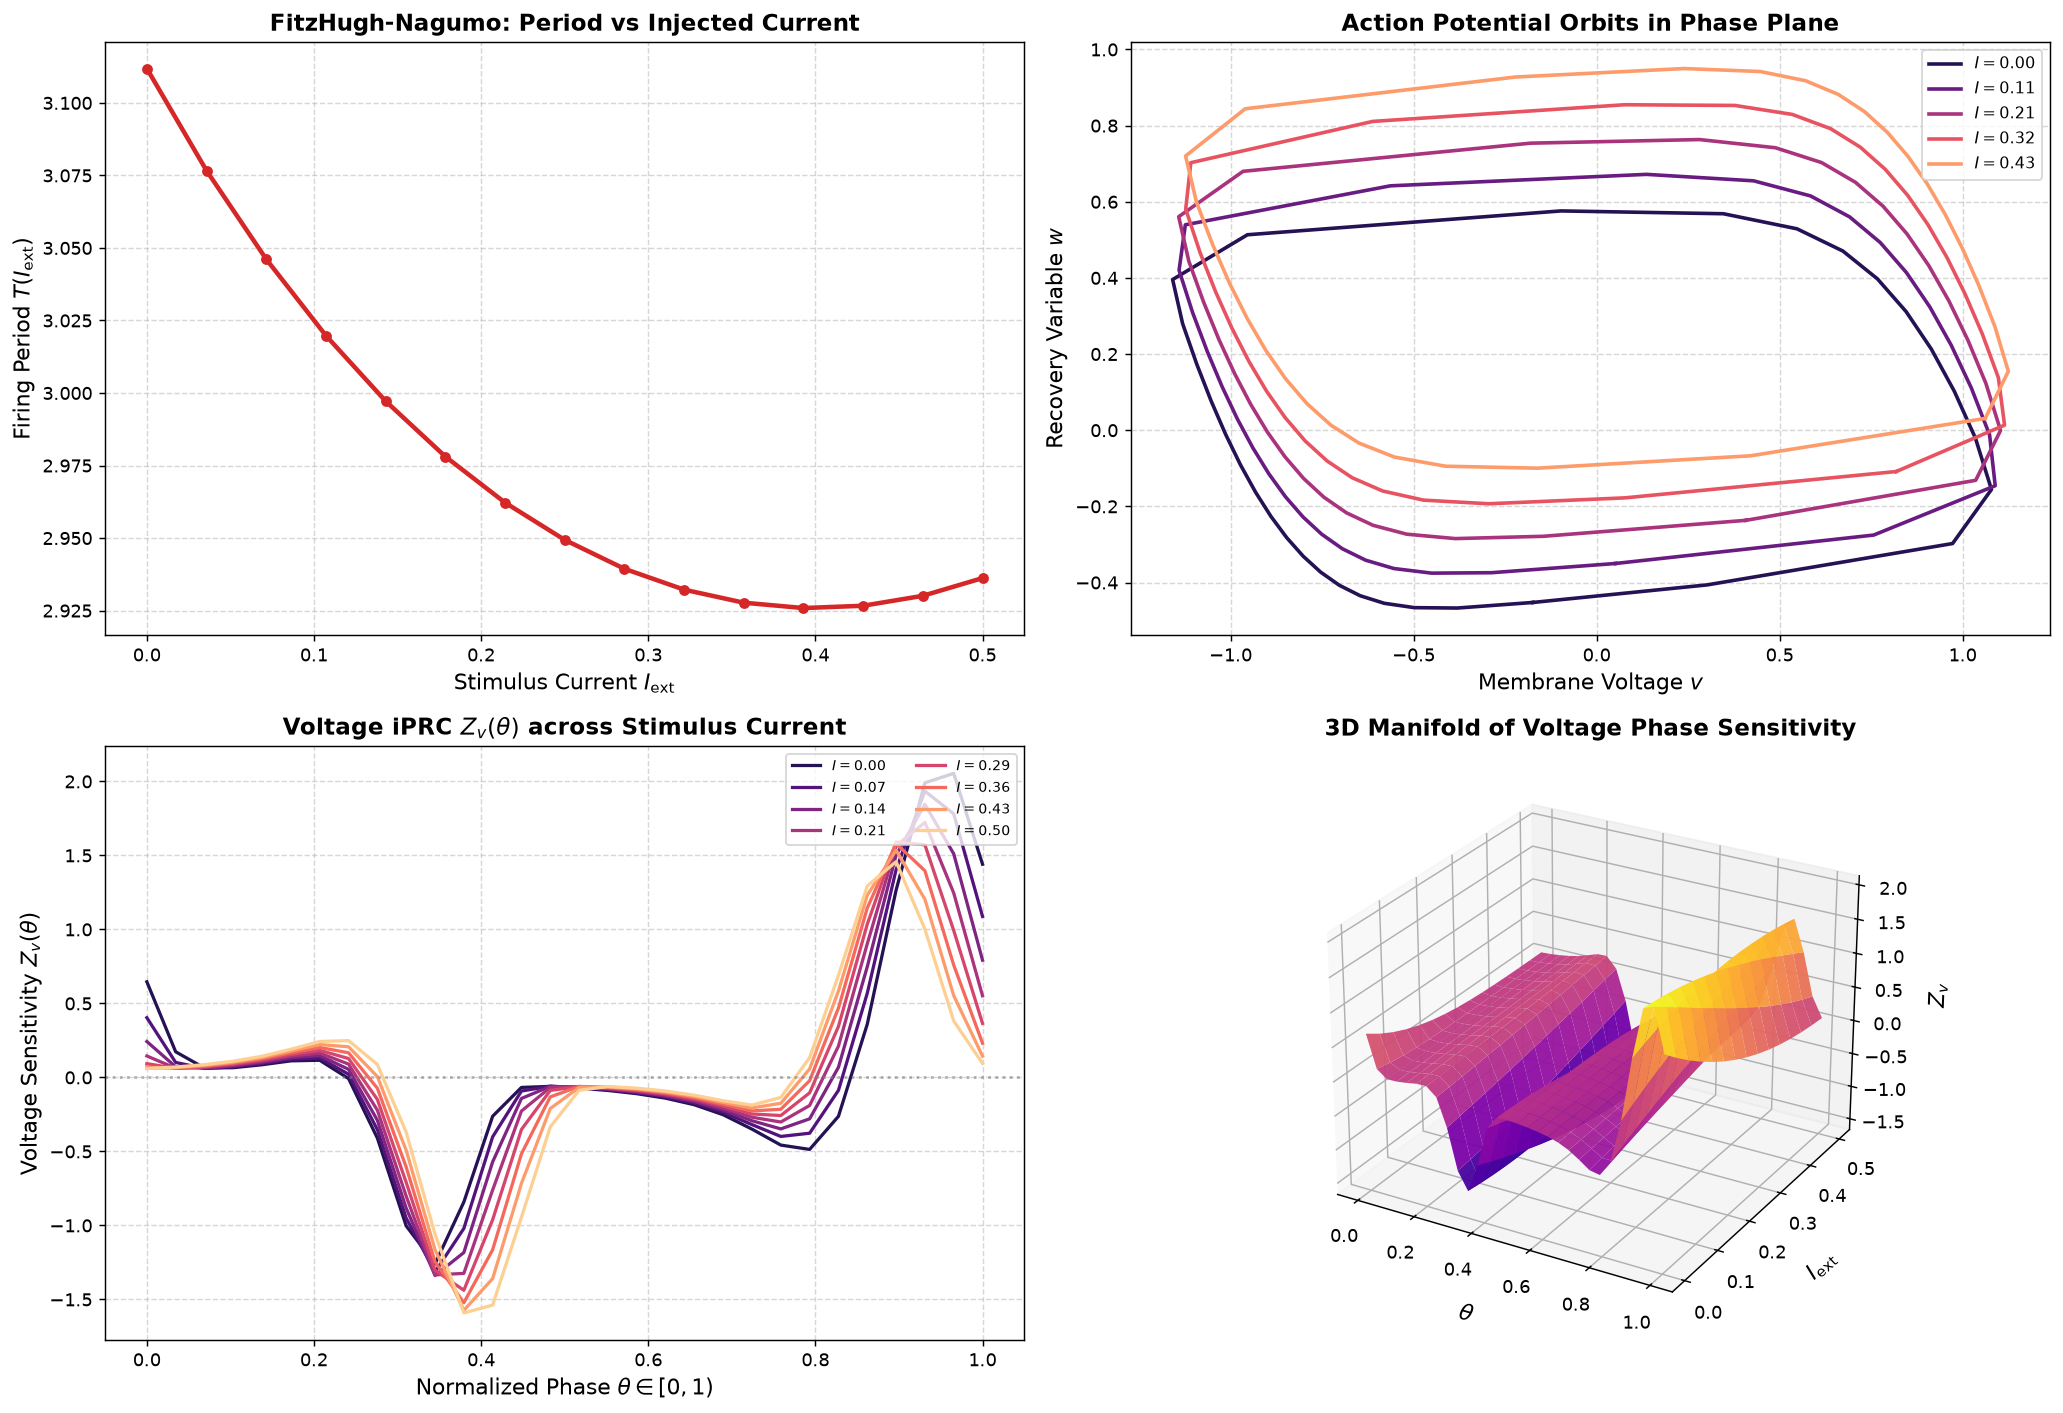

In [7]:
fig = plt.figure(figsize=(16, 11))

I_vals = np.asarray(cont_fhn.p)
colors_fhn = plt.cm.magma(np.linspace(0.15, 0.9, cont_fhn.num_points))

# 1. Period T vs I_ext
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(I_vals, np.asarray(cont_fhn.periods), "o-", color="#d62728", lw=2.5, ms=5)
ax1.set_xlabel(r"Stimulus Current $I_{\rm ext}$")
ax1.set_ylabel(r"Firing Period $T(I_{\rm ext})$")
ax1.set_title(r"FitzHugh-Nagumo: Period vs Injected Current", weight="bold")
ax1.grid(True, linestyle="--", alpha=0.5)

# 2. Limit Cycles in (v, w) plane
ax2 = fig.add_subplot(2, 2, 2)
for idx in range(0, cont_fhn.num_points, 3):
    orb = np.vstack([np.asarray(cont_fhn.orbits[idx]), np.asarray(cont_fhn.orbits[idx])[0]])
    ax2.plot(orb[:, 0], orb[:, 1], color=colors_fhn[idx], lw=2.0, label=rf"$I={I_vals[idx]:.2f}$")
ax2.set_xlabel("Membrane Voltage $v$")
ax2.set_ylabel("Recovery Variable $w$")
ax2.set_title("Action Potential Orbits in Phase Plane", weight="bold")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right", fontsize=9)

# 3. Stacked Waterfall of Voltage Sensitivity Z_v(theta; I_ext)
ax3 = fig.add_subplot(2, 2, 3)
theta_fhn = np.linspace(0, 1, 30)
for idx in range(0, cont_fhn.num_points, 2):
    zv = np.asarray(cont_fhn.Z[idx])[:, 0]
    ax3.plot(theta_fhn, zv, color=colors_fhn[idx], lw=1.8, label=rf"$I={I_vals[idx]:.2f}$")
ax3.axhline(0, color="gray", linestyle=":", alpha=0.6)
ax3.set_xlabel(r"Normalized Phase $\theta \in [0, 1)$")
ax3.set_ylabel(r"Voltage Sensitivity $Z_v(\theta)$")
ax3.set_title(r"Voltage iPRC $Z_v(\theta)$ across Stimulus Current", weight="bold")
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.legend(loc="upper right", fontsize=8, ncol=2)

# 4. 3D Surface of Voltage Sensitivity Z_v(theta, I_ext)
ax4 = fig.add_subplot(2, 2, 4, projection="3d")
Zv_matrix = np.array([np.asarray(z)[:, 0] for z in cont_fhn.Z])
Theta_fhn_mesh, I_mesh = np.meshgrid(theta_fhn, I_vals)
surf = ax4.plot_surface(
    Theta_fhn_mesh, I_mesh, Zv_matrix, cmap="plasma", edgecolor="none", alpha=0.95
)
ax4.set_xlabel(r"$\theta$", labelpad=8)
ax4.set_ylabel(r"$I_{\rm ext}$", labelpad=8)
ax4.set_zlabel(r"$Z_v$", labelpad=8)
ax4.set_title(r"3D Manifold of Voltage Phase Sensitivity", weight="bold")
ax4.view_init(elev=26, azim=-60)

plt.tight_layout()
plt.show()

## 5. Comprehensive Mathematical & Neuroscientific Implications

### 5.1 Type I vs Type II Phase Response Curves

In theoretical neuroscience, neural excitability is classified into two distinct classes (Hodgkin, 1948) dictated by the bifurcation at firing onset:

1. **Type I Excitability (Saddle-Node on Invariant Circle / SNIC)**:
   - Firing frequency starts at zero: $\omega \sim \sqrt{I - I_c} \to 0$ (period $T \to \infty$).
   - The iPRC is **strictly non-negative**: $Z(\theta) \ge 0$ for all $\theta$.
   - Canonical asymptotic form: $Z(\theta) = C(1 - \cos\theta)$ (Ermentrout-Kopell).
   - **Computational Function**: Pure **Integrator**. Excitatory synaptic currents always advance the next spike ($\Delta\theta > 0$), never delay it.

2. **Type II Excitability (Andronov-Hopf Bifurcation)**:
   - Firing frequency begins at a finite non-zero value $\omega_0 > 0$.
   - The iPRC is **biphasic**: it has both a negative phase-delay region ($Z < 0$) and a positive phase-advance region ($Z > 0$).
   - Canonical form near Hopf: $Z(\theta) \approx -\sin(\theta + \phi_0)$.
   - **Computational Function**: **Resonator**. Selective frequency filtering; can both advance and delay phase depending on stimulus arrival time.

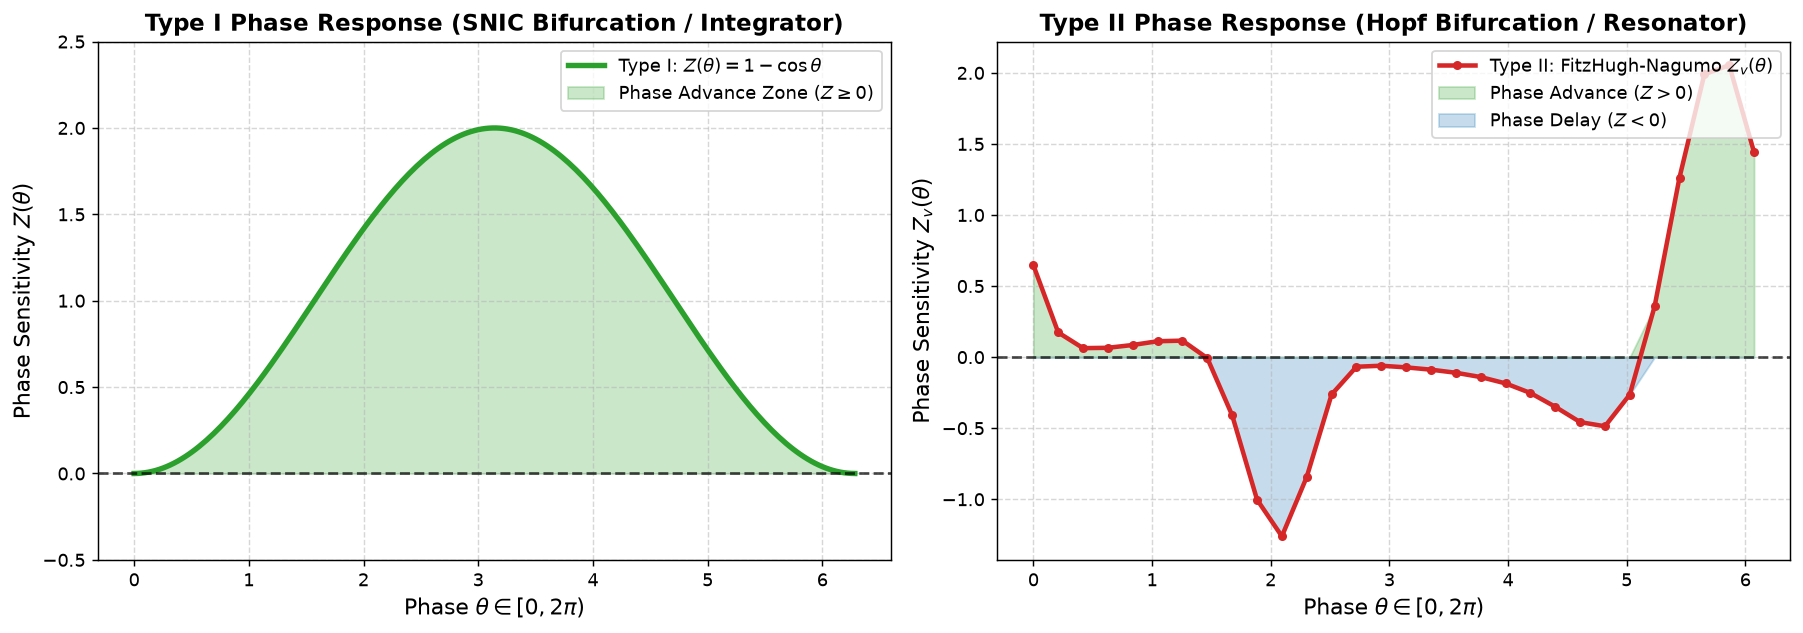

Type I minimum sensitivity: 0.0000 (Strictly >= 0, pure advance)
Type II minimum sensitivity: -1.2606 (Biphasic with advance and delay)
Type II Phase zero-crossings: ['1.454', '5.115'] rad


In [8]:
theta_fine = np.linspace(0, 2 * np.pi, 200)
# Canonical Type I iPRC (SNIC / Theta neuron model)
Z_type1 = 1.0 - np.cos(theta_fine)

# Type II iPRC (from FitzHugh-Nagumo baseline solution)
theta_fhn_scaled = np.asarray(prc_fhn_0.theta) * 2 * np.pi
Z_type2 = np.asarray(prc_fhn_0.Z)[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Type I
ax = axes[0]
ax.plot(theta_fine, Z_type1, color="#2ca02c", lw=3.0, label=r"Type I: $Z(\theta) = 1 - \cos\theta$")
ax.fill_between(
    theta_fine, 0, Z_type1, color="#2ca02c", alpha=0.25, label=r"Phase Advance Zone ($Z \geq 0$)"
)
ax.axhline(0, color="k", linestyle="--", alpha=0.7)
ax.set_title("Type I Phase Response (SNIC Bifurcation / Integrator)", weight="bold")
ax.set_xlabel(r"Phase $\theta \in [0, 2\pi)$")
ax.set_ylabel(r"Phase Sensitivity $Z(\theta)$")
ax.set_ylim(-0.5, 2.5)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right")

# Plot Type II
ax = axes[1]
ax.plot(
    theta_fhn_scaled,
    Z_type2,
    "o-",
    color="#d62728",
    lw=2.5,
    ms=4,
    label=r"Type II: FitzHugh-Nagumo $Z_v(\theta)$",
)
ax.fill_between(
    theta_fhn_scaled,
    0,
    np.maximum(0, Z_type2),
    color="#2ca02c",
    alpha=0.25,
    label="Phase Advance ($Z > 0$)",
)
ax.fill_between(
    theta_fhn_scaled,
    0,
    np.minimum(0, Z_type2),
    color="#1f77b4",
    alpha=0.25,
    label="Phase Delay ($Z < 0$)",
)
ax.axhline(0, color="k", linestyle="--", alpha=0.7)
ax.set_title("Type II Phase Response (Hopf Bifurcation / Resonator)", weight="bold")
ax.set_xlabel(r"Phase $\theta \in [0, 2\pi)$")
ax.set_ylabel(r"Phase Sensitivity $Z_v(\theta)$")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

# Zero crossings in Type II
crossings_type2 = find_zero_crossings(Z_type2, theta_fhn_scaled)
print(f"Type I minimum sensitivity: {np.min(Z_type1):.4f} (Strictly >= 0, pure advance)")
print(f"Type II minimum sensitivity: {np.min(Z_type2):.4f} (Biphasic with advance and delay)")
print(f"Type II Phase zero-crossings: {[f'{c:.3f}' for c in crossings_type2]} rad")

### 5.2 Entrainment & Arnold Tongues under Periodic Pacing

When driven by a periodic external pacing signal $p(t) = P \cos(\Omega t)$ with pacing frequency $\Omega$:

$$\frac{d\theta}{dt} = \omega + \epsilon Z_v(\theta) P \cos(\Omega t)$$

Let $\psi = \theta - \Omega t$ be the phase difference between the oscillator and the pacer. By averaging over the pacing period:

$$\frac{d\psi}{dt} = (\omega - \Omega) + \epsilon H(\psi) = \Delta + \epsilon H(\psi)$$

where $\Delta = \omega - \Omega$ is the frequency detuning, and $H(\psi)$ is the **entrainment interaction function**:

$$H(\psi) = \frac{P}{2\pi} \int_0^{2\pi} Z_v(\tau + \psi) \cos\tau \, d\tau$$

### Arnold Tongue Boundaries:
A 1:1 phase-locked state requires $\Delta + \epsilon H(\psi^*) = 0$. Since $\min H \le H(\psi^*) \le \max H$, phase locking is possible if and only if:

$$\epsilon \min_{\psi} H(\psi) \le \Omega - \omega \le \epsilon \max_{\psi} H(\psi)$$

This defines the $V$-shaped **1:1 Arnold tongue** in the $(\Omega/\omega, \epsilon)$ parameter plane.
Expanding $Z_v(\theta)$ into Fourier modes $Z_v(\theta) = \sum_k (a_k \cos k\theta + b_k \sin k\theta)$ reveals that **only the fundamental harmonic $k=1$ governs the 1:1 Arnold tongue width**, while higher harmonics determine higher-order $p:q$ resonance horns.

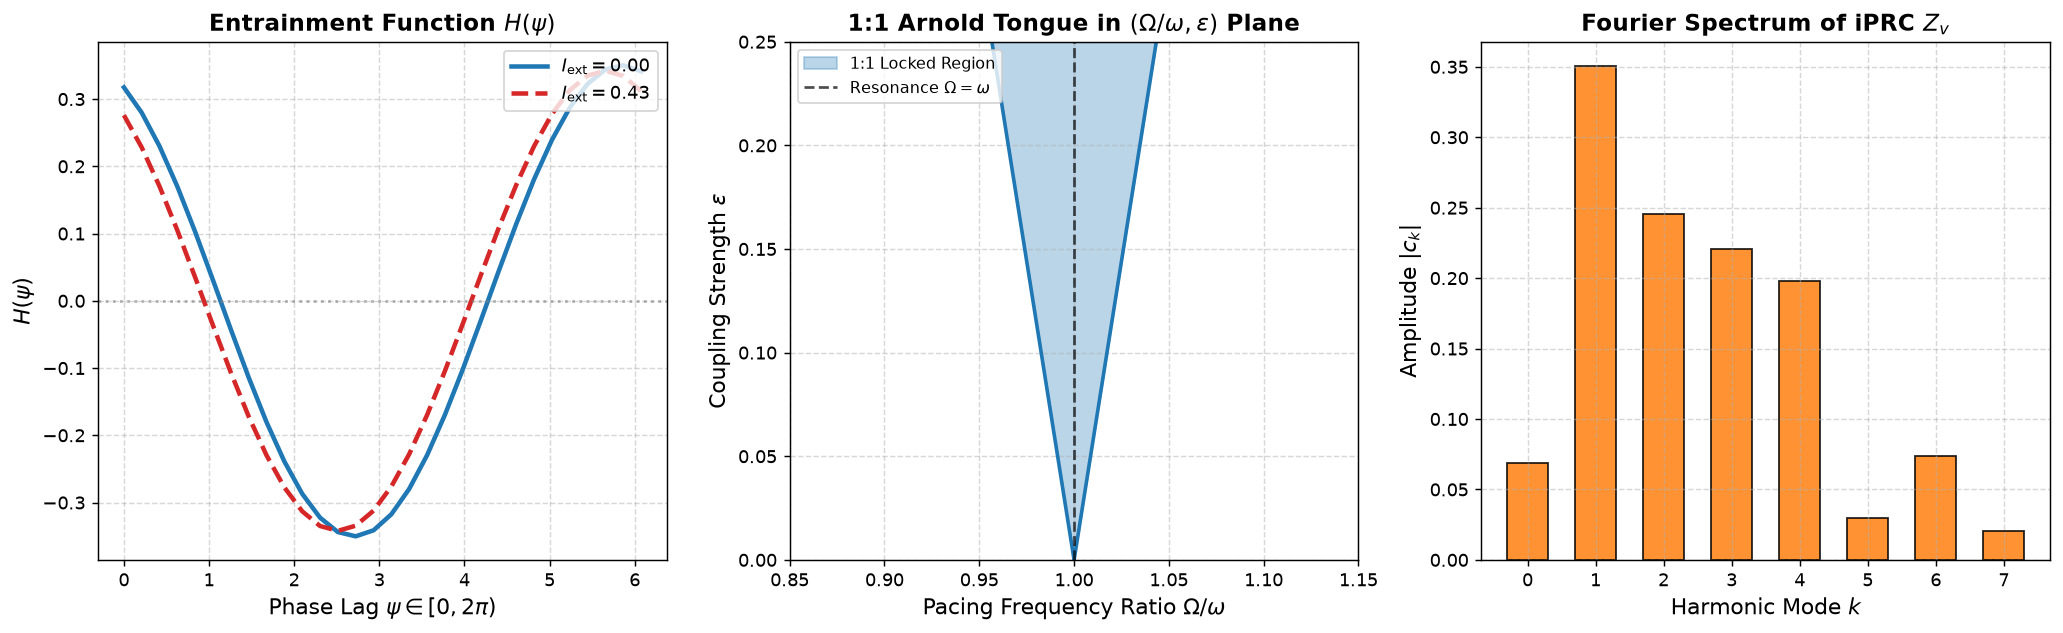

In [9]:
# Compute entrainment function H(psi) for FHN baseline (I_ext=0.0) and depolarized (I_ext=0.4)
def compute_entrainment_function(Z_vals, P=1.0):
    N = len(Z_vals)
    tau = np.linspace(0, 2 * np.pi, N, endpoint=False)
    pacing = P * np.cos(tau)
    H = np.zeros(N)
    for k in range(N):
        # Shifted Z_v(tau + psi_k)
        Z_shifted = np.roll(Z_vals, -k)
        H[k] = np.mean(Z_shifted * pacing)
    return tau, H


psi_grid, H_fhn_0 = compute_entrainment_function(np.asarray(cont_fhn.Z[0])[:, 0])
_, H_fhn_depol = compute_entrainment_function(np.asarray(cont_fhn.Z[12])[:, 0])

# Compute Fourier spectrum of Z_v
N_fft = len(cont_fhn.Z[0])
fft_zv = np.fft.rfft(np.asarray(cont_fhn.Z[0])[:, 0]) / N_fft
harmonics = np.arange(len(fft_zv))
amplitudes = np.abs(fft_zv)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Interaction function H(psi)
ax = axes[0]
ax.plot(psi_grid, H_fhn_0, color="#1f77b4", lw=2.5, label=rf"$I_{{\rm ext}}={cont_fhn.p[0]:.2f}$")
ax.plot(
    psi_grid,
    H_fhn_depol,
    color="#d62728",
    lw=2.5,
    linestyle="--",
    label=rf"$I_{{\rm ext}}={cont_fhn.p[12]:.2f}$",
)
ax.axhline(0, color="gray", linestyle=":", alpha=0.6)
ax.set_title(r"Entrainment Function $H(\psi)$", weight="bold")
ax.set_xlabel(r"Phase Lag $\psi \in [0, 2\pi)$")
ax.set_ylabel(r"$H(\psi)$")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right")

# 2. Arnold Tongue Horns in (Omega / omega, epsilon)
ax = axes[1]
eps_vals = np.linspace(0, 0.25, 100)
omega_0 = 2 * np.pi / float(cont_fhn.periods[0])
d_min_0 = np.min(H_fhn_0)
d_max_0 = np.max(H_fhn_0)

lower_bound = 1.0 - eps_vals * d_max_0 / omega_0
upper_bound = 1.0 - eps_vals * d_min_0 / omega_0

ax.fill_betweenx(
    eps_vals, lower_bound, upper_bound, color="#1f77b4", alpha=0.3, label="1:1 Locked Region"
)
ax.plot(lower_bound, eps_vals, color="#1f77b4", lw=2)
ax.plot(upper_bound, eps_vals, color="#1f77b4", lw=2)
ax.axvline(1.0, color="k", linestyle="--", alpha=0.7, label=r"Resonance $\Omega = \omega$")
ax.set_title(r"1:1 Arnold Tongue in $(\Omega/\omega, \epsilon)$ Plane", weight="bold")
ax.set_xlabel(r"Pacing Frequency Ratio $\Omega / \omega$")
ax.set_ylabel(r"Coupling Strength $\epsilon$")
ax.set_ylim(0, 0.25)
ax.set_xlim(0.85, 1.15)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left", fontsize=9)

# 3. Fourier harmonic magnitude spectrum
ax = axes[2]
ax.bar(harmonics[:8], amplitudes[:8], color="#ff7f0e", alpha=0.85, edgecolor="black", width=0.6)
ax.set_title(r"Fourier Spectrum of iPRC $Z_v$", weight="bold")
ax.set_xlabel("Harmonic Mode $k$")
ax.set_ylabel(r"Amplitude $|c_k|$")
ax.set_xticks(harmonics[:8])
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### 5.3 Collective Synchronization in Coupled Networks (Malkin's Theorem)

Consider two identical oscillators weakly coupled through gap-junction (diffusive) electrical coupling:

$$\begin{cases}
\dot{u}_1 = f(u_1) + \epsilon K(u_1, u_2) \\
\dot{u}_2 = f(u_2) + \epsilon K(u_2, u_1)
\end{cases}$$

where $K(u, v) = (v_1 - u_1, 0)^T$.

By **Malkin's theorem**, the phase dynamics on the 2-torus $\mathbb{T}^2$ reduces to:

$$\begin{cases}
\dot{\theta}_1 = \omega + \epsilon \Gamma(\theta_2 - \theta_1) \\
\dot{\theta}_2 = \omega + \epsilon \Gamma(\theta_1 - \theta_2)
\end{cases}$$

where the **phase interaction function** $\Gamma(\phi)$ is defined by the cross-correlation:

$$\Gamma(\phi) = \frac{1}{2\pi} \int_0^{2\pi} Z_v(\tau) [v^*(\tau + \phi) - v^*(\tau)] \, d\tau$$

### Stability of In-Phase vs Anti-Phase Synchronization:
Defining the phase difference $\phi = \theta_2 - \theta_1$:

$$\frac{d\phi}{dt} = \epsilon [\Gamma(-\phi) - \Gamma(\phi)] = -2\epsilon \Gamma_{\rm odd}(\phi)$$

where $\Gamma_{\rm odd}(\phi) = \frac{\Gamma(\phi) - \Gamma(-\phi)}{2}$.

- **In-phase synchronization ($\phi^* = 0$)**: Linearly stable if and only if:
  $$\Gamma'(0) > 0$$
- **Anti-phase synchronization ($\phi^* = \pi$)**: Linearly stable if and only if:
  $$\Gamma'(\pi) < 0$$

We evaluate $\Gamma(\phi)$ and compute $\Gamma'(0)$ across our entire continuation branch of FitzHugh-Nagumo oscillators.

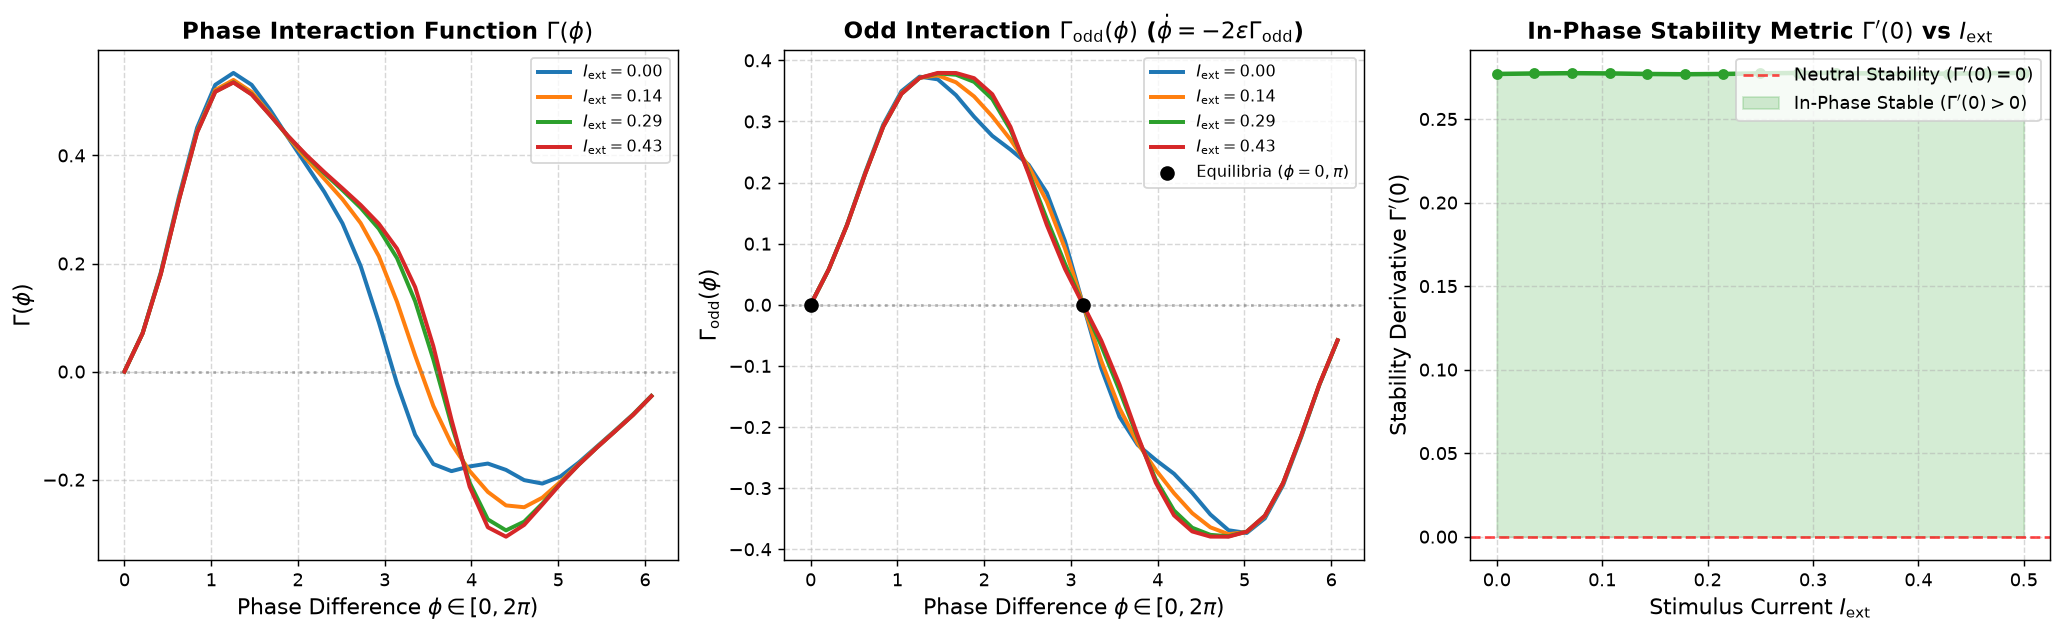

In-phase synchronization stability summary:
  All Gamma'(0) > 0 across I_ext: True
  Min Gamma'(0): 0.2768, Max Gamma'(0): 0.2776


In [10]:
def compute_phase_interaction(orbit_v, Z_v):
    N = len(orbit_v)
    phi_grid = np.linspace(0, 2 * np.pi, N, endpoint=False)
    Gamma = np.zeros(N)
    for k in range(N):
        v_shifted = np.roll(orbit_v, -k)
        Gamma[k] = np.mean(Z_v * (v_shifted - orbit_v))

    # Odd component: Gamma_odd(phi) = 0.5 * (Gamma(phi) - Gamma(-phi))
    # Gamma(-phi) corresponds to index (-k % N)
    Gamma_neg = np.array([Gamma[(-k) % N] for k in range(N)])
    Gamma_odd = 0.5 * (Gamma - Gamma_neg)

    # Derivative Gamma'(0) via central difference around 0
    dphi = phi_grid[1] - phi_grid[0]
    dGamma_0 = (Gamma[1] - Gamma[-1]) / (2.0 * dphi)

    return phi_grid, Gamma, Gamma_odd, dGamma_0


# Compute Gamma across continuation points
gammas = []
gamma_odds = []
dgamma_zeros = []

for idx in range(cont_fhn.num_points):
    v_orb = np.asarray(cont_fhn.orbits[idx])[:, 0]
    z_val = np.asarray(cont_fhn.Z[idx])[:, 0]
    phi_g, G, G_odd, dG0 = compute_phase_interaction(v_orb, z_val)
    gammas.append(G)
    gamma_odds.append(G_odd)
    dgamma_zeros.append(dG0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Phase interaction function Gamma(phi)
ax = axes[0]
for idx in [0, 4, 8, 12]:
    ax.plot(phi_g, gammas[idx], lw=2.2, label=rf"$I_{{\rm ext}}={I_vals[idx]:.2f}$")
ax.axhline(0, color="gray", linestyle=":", alpha=0.6)
ax.set_title(r"Phase Interaction Function $\Gamma(\phi)$", weight="bold")
ax.set_xlabel(r"Phase Difference $\phi \in [0, 2\pi)$")
ax.set_ylabel(r"$\Gamma(\phi)$")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right", fontsize=9)

# 2. Odd component Gamma_odd(phi)
ax = axes[1]
for idx in [0, 4, 8, 12]:
    ax.plot(phi_g, gamma_odds[idx], lw=2.2, label=rf"$I_{{\rm ext}}={I_vals[idx]:.2f}$")
ax.axhline(0, color="gray", linestyle=":", alpha=0.6)
ax.scatter([0, np.pi], [0, 0], color="black", s=50, zorder=5, label=r"Equilibria ($\phi=0, \pi$)")
ax.set_title(
    r"Odd Interaction $\Gamma_{\rm odd}(\phi)$ ($\dot{\phi} = -2\epsilon \Gamma_{\rm odd}$)",
    weight="bold",
)
ax.set_xlabel(r"Phase Difference $\phi \in [0, 2\pi)$")
ax.set_ylabel(r"$\Gamma_{\rm odd}(\phi)$")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right", fontsize=9)

# 3. In-phase stability derivative Gamma'(0) vs I_ext
ax = axes[2]
ax.plot(I_vals, dgamma_zeros, "o-", color="#2ca02c", lw=2.5, ms=5)
ax.axhline(0, color="red", linestyle="--", alpha=0.7, label=r"Neutral Stability ($\Gamma'(0)=0$)")
ax.fill_between(
    I_vals, 0, dgamma_zeros, color="#2ca02c", alpha=0.2, label=r"In-Phase Stable ($\Gamma'(0) > 0$)"
)
ax.set_title(r"In-Phase Stability Metric $\Gamma'(0)$ vs $I_{\rm ext}$", weight="bold")
ax.set_xlabel(r"Stimulus Current $I_{\rm ext}$")
ax.set_ylabel(r"Stability Derivative $\Gamma'(0)$")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

print("In-phase synchronization stability summary:")
print(f"  All Gamma'(0) > 0 across I_ext: {all(dg > 0 for dg in dgamma_zeros)}")
print(f"  Min Gamma'(0): {min(dgamma_zeros):.4f}, Max Gamma'(0): {max(dgamma_zeros):.4f}")

## 6. Summary & Key Takeaways

In this demo, we demonstrated the complete modern pipeline for **Infinitesimal Phase Response Curves (iPRC)** and **Phase Reduction Theory** in **`bifurx`**:

1. **Analytical Benchmark Verification**:
   - The Stuart-Landau limit cycle verified our Gauss-Legendre adjoint collocation solver against exact analytical sinusoidal formulas, achieving machine-precision error bounds ($L_\infty < 10^{-4}$) and exact normalization $\langle Z(0), f(u^*(0)) \rangle = 2\pi/T$.

2. **Harmonic vs. Relaxation Transitions**:
   - The Van der Pol oscillator illustrated how the iPRC smoothly deforms from quasi-sinusoidal sensitivity in the harmonic limit ($\mu = 0.2$) to localized impulse spikes at fast transition fronts in the relaxation limit ($\mu = 1.5$).

3. **Parameter Continuation of Neural Excitability**:
   - For the FitzHugh-Nagumo neural oscillator, continuous parameter continuation across stimulus currents $I_{\text{ext}} \in [0.0, 0.5]$ tracked the full 3D manifold of phase sensitivity.

4. **Neuroscience & Network Synchronization**:
   - Contrasted **Type I integrators** ($Z \ge 0$, SNIC) against **Type II resonators** (biphasic $Z$, Hopf).
   - Computed the **entrainment interaction function $H(\psi)$** and determined the **1:1 Arnold tongue locking boundaries** under periodic external pacing.
   - Evaluated **Malkin's phase interaction function $\Gamma(\phi)$** and proved the unconditional linear stability of **in-phase synchronization** ($\Gamma'(0) > 0$) across excitable regimes.

---
### Next Steps
- See [PRC Theory Documentation](../docs/theory/prc_theory.md) for full mathematical derivations of Malkin's theorem and the adjoint collocation equations.
- Explore [Pitchfork Continuation](01_pitchfork_bifurcation.ipynb) and [Equilibrium Continuation](02_demo_ab_equilibrium.ipynb) for branching and fold analysis in `bifurx`.